In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
from itertools import combinations

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import pytaxonkit
import scipy.stats as stats
import seaborn as sns
from tqdm import tqdm

from helper import summarize_category_counts
from amr_plot_helpers import (
    plot_resistance_rate,
    plot_mic_breakpoint_heatmap,
    plot_mic_pairwise_correlation,
    can_merge,
    can_merge_class,
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
PALETTE = {
    "susceptible":               "#26de81",
    "intermediate":              "#778ca3",
    "resistant":                 "#fc5c65",
    "not defined":               "#d1d8e0",
    "susceptible-dose dependent":"#2bcbba",
    "nonsusceptible":            "#fd9644",
}

PHENO_ORDER = [
    "susceptible",
    "susceptible-dose dependent",
    "intermediate",
    "nonsusceptible",
    "resistant",
    "not defined",
]

PHENOTYPE_COLORS = {
    "susceptible":                "#4C9BE8",
    "susceptible-dose dependent": "#85C1E9",
    "intermediate":               "#F0B93A",
    "nonsusceptible":             "#E08C3A",
    "resistant":                  "#E05C5C",
    "not defined":                "#AAAAAA",
}

ISOLATION_MARKERS = {
    "clinical":            "o",
    "environmental/other": "^",
}

SHORT_LABELS = {
    "susceptible":                "S",
    "susceptible-dose dependent": "SDD",
    "intermediate":               "I",
    "nonsusceptible":             "NS",
    "resistant":                  "R",
    "not defined":                "ND",
}

In [3]:
DATA_DIR      = "/Users/akshayonly/Main/Projects/amr-geno2dock/data"
NOTEBOOK_DIR  = "/Users/akshayonly/Main/Projects/amr-geno2dock/notebooks"
AST_PATH      = f"{DATA_DIR}/asts.tsv"
CLASSES_PATH  = f"{NOTEBOOK_DIR}/antibiotics_classes.csv"
ACCESSIONS_PATH = f"{NOTEBOOK_DIR}/assembly_ids.txt"
SUMMARIES_DIR = "summaries"
PLOTS_DIR     = "plots"

os.makedirs(SUMMARIES_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

## SECTION 1 — Load & normalise AST records

In [4]:
KEEP_COLS = [
    '#BioSample', 'Antibiotic', 'Resistance phenotype', 'Isolation type',
    'Testing standard', 'Measurement sign', 'MIC (mg/L)', 'Scientific name',
]

records = pd.read_csv(AST_PATH, sep='\t', usecols=KEEP_COLS, engine='c')

records['Resistance phenotype'] = records['Resistance phenotype'].str.strip().str.lower()
records['Measurement sign']     = records['Measurement sign'].replace('==', '=')
records['Species']              = records['Scientific name'].str.extract(r'^(\S+\s+\S+)')

records = records.drop_duplicates(
    subset=['#BioSample', 'Antibiotic', 'Resistance phenotype']
)

## SECTION 2 — Merge antibiotic classes and assembly accessions

In [5]:
antibiotics_class = pd.read_csv(CLASSES_PATH)
records = pd.merge(records, antibiotics_class).drop_duplicates()

accessions = pd.read_csv(
    ACCESSIONS_PATH, sep='\t', names=['#BioSample', 'Assembly_Accession']
)
records = (
    pd.merge(records, accessions, on='#BioSample')
    .drop_duplicates()
)

## SECTION 3 — Attach taxonomy via TaxID

In [6]:
names  = records['Species'].dropna().unique().tolist()
taxids = pytaxonkit.name2taxid(names, threads=6)
taxids = (
    taxids
    .dropna(subset=['TaxID'])
    .drop_duplicates(subset=['Name'])
)
taxids['TaxID'] = pd.to_numeric(taxids['TaxID'], errors='coerce').astype('Int64')
taxids = taxids.dropna(subset=['TaxID'])

taxon_data = pytaxonkit.lineage(
    taxids['TaxID'].astype(int).tolist(),
    formatstr="{phylum};{class};{order};{genus}",
    threads=6,
)
taxon_data['TaxID'] = pd.to_numeric(taxon_data['TaxID'], errors='coerce').astype('Int64')

SPLIT_COLS = ['Phylum', 'Class', 'Order', 'Genus']
split_data = (
    taxon_data['Lineage']
    .fillna('')
    .str.split(';', expand=True)
    .reindex(columns=range(len(SPLIT_COLS)))
)
split_data.columns = SPLIT_COLS
split_data = split_data.replace('', pd.NA)

taxon_data = (
    pd.concat([taxon_data[['TaxID']], split_data], axis=1)
    .merge(taxids[['Name', 'TaxID']], on='TaxID', how='left')
    .rename(columns={'Name': 'Species'})
    [['Species', 'TaxID'] + SPLIT_COLS]
)

records = pd.merge(records, taxon_data, on='Species').drop_duplicates().reset_index(drop=True)

## SECTION 4 — Export per-species summary files

In [7]:
# WHO Bacterial Priority Pathogens List 2024
BPPL_2024_SPECIES = [
    "Acinetobacter baumannii",
    "Salmonella Typhi",
    "Enterococcus faecium",
    "Pseudomonas aeruginosa",
    "Staphylococcus aureus",
    "Mycobacterium tuberculosis",
    "Streptococcus pneumoniae",
    "Haemophilus influenzae",
    "Neisseria gonorrhoeae",
]

SKIP_COLS = {'#BioSample', 'Assembly_Accession'}

for species_name in BPPL_2024_SPECIES:
    safe_name = "".join(
        c for c in species_name if c.isalnum() or c in (" ", "_", "-")
    ).rstrip()

    # Antibiotic class summary
    _, counts = summarize_category_counts(
        records,
        category_column='Species',
        category_value=species_name,
        groupby_column='Antibiotic_Class',
    )
    with open(f"{SUMMARIES_DIR}/{safe_name}_antibiotic_class_summary.txt", 'w', encoding='utf-8') as f:
        f.write(f"{'-' * 10} Top 10 Antibiotic Classes for {species_name} {'-' * 10}\n")
        f.write(f"{counts.head(10).to_string()}\n")

    # Full column value-counts summary
    species_df = records[records['Species'] == species_name]
    with open(f"{SUMMARIES_DIR}/{safe_name}.txt", 'w', encoding='utf-8') as f:
        for col, data in species_df.items():
            if col in SKIP_COLS:
                continue
            f.write(f"{'-' * 10} {col} {'-' * 10}\n")
            f.write(f"{data.value_counts().to_string()}\n\n")

    print(f"Summaries saved: {safe_name}\n")


Species: Acinetobacter baumannii
No. unique BioSamples: 812
Summaries saved: Acinetobacter baumannii

Species: Salmonella Typhi
No. unique BioSamples: 0
Summaries saved: Salmonella Typhi

Species: Enterococcus faecium
No. unique BioSamples: 36
Summaries saved: Enterococcus faecium

Species: Pseudomonas aeruginosa
No. unique BioSamples: 627
Summaries saved: Pseudomonas aeruginosa

Species: Staphylococcus aureus
No. unique BioSamples: 739
Summaries saved: Staphylococcus aureus

Species: Mycobacterium tuberculosis
No. unique BioSamples: 0
Summaries saved: Mycobacterium tuberculosis

Species: Streptococcus pneumoniae
No. unique BioSamples: 188
Summaries saved: Streptococcus pneumoniae

Species: Haemophilus influenzae
No. unique BioSamples: 0
Summaries saved: Haemophilus influenzae

Species: Neisseria gonorrhoeae
No. unique BioSamples: 701
Summaries saved: Neisseria gonorrhoeae



## SECTION 5 — Select species × antibiotic class

In [8]:
species_name = 'Pseudomonas aeruginosa'
records[records['Species']==species_name]['Antibiotic_Class'].value_counts().reset_index().head(5)

,Antibiotic_Class,count
0,Aminoglycoside,1452
1,Fluoroquinolone,1035
2,Carbapenem,675
3,Cephalosporin (3rd generation),422
4,Cephalosporin (4th generation),384


In [9]:
records[records['Species']==species_name]['Testing standard'].value_counts()

Testing standard
CLSI    4830
Name: count, dtype: int64

In [10]:
ab_class     = 'Aminoglycoside'

selected_records = records[
    (records['Species']          == species_name) &
    (records['Antibiotic_Class'] == ab_class)     &
    (records['Testing standard'] == 'CLSI')
].copy()

plot_data = (
    selected_records[['Isolation type', 'Antibiotic', 'Resistance phenotype', 'MIC (mg/L)']]
    .copy()
)

print(f"\nSelected: {species_name} × {ab_class}")
print(selected_records['Antibiotic'].value_counts())



Selected: Pseudomonas aeruginosa × Aminoglycoside
Antibiotic
gentamicin       543
amikacin         455
tobramycin       449
streptomycin       3
neomycin           1
spectinomycin      1
Name: count, dtype: int64


## SECTION 6 — Visualisations

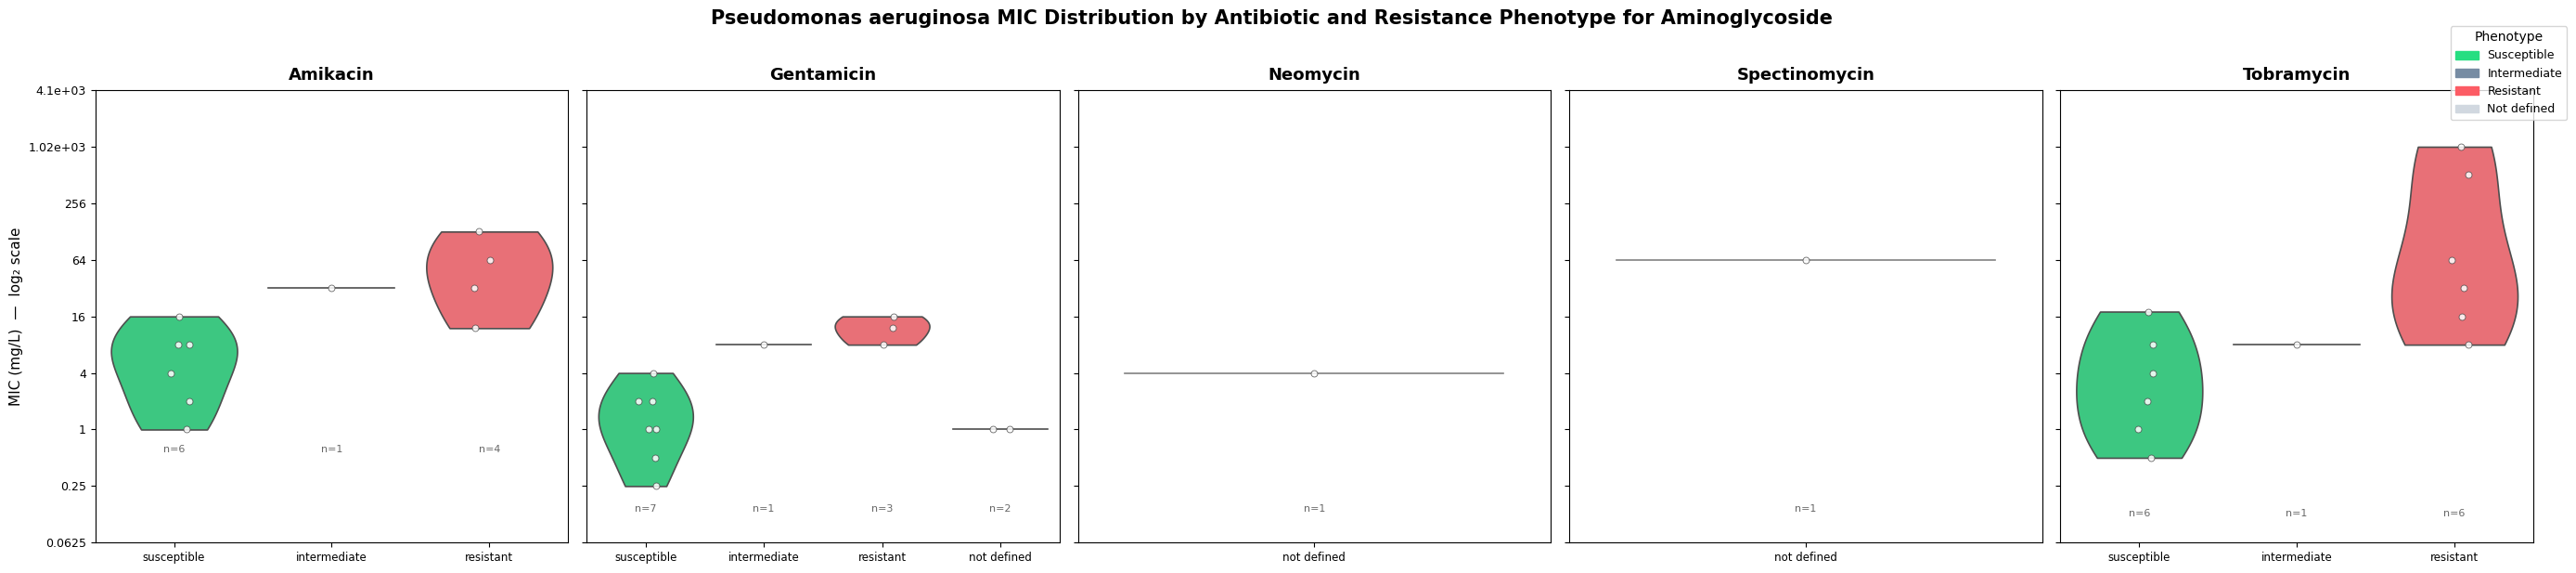

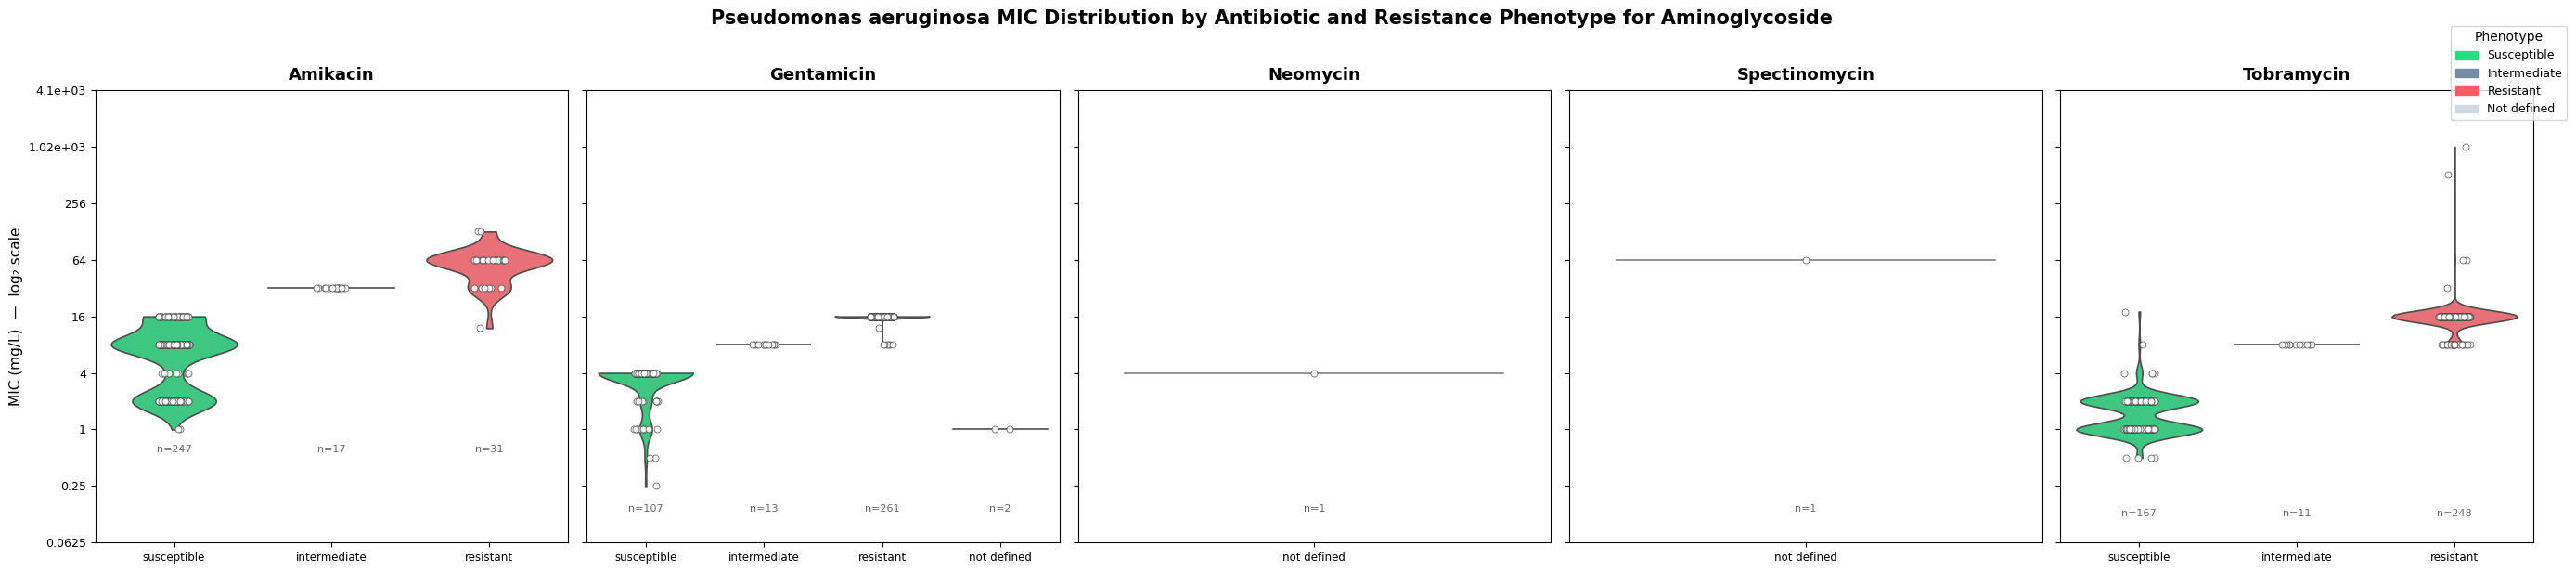

In [11]:

def _save(fname: str) -> str:
    return f"{PLOTS_DIR}/{species_name}_{ab_class}_{fname}.png"


# ── 6a. Violin plot ───────────────────────────────────────────────────────────

def plot_mic_violin(
    plot_data: pd.DataFrame,
    species_name: str = "",
    ab_class: str = "",
) -> plt.Figure:
    """
    Violin + strip plot of MIC distributions per antibiotic,
    coloured by resistance phenotype category.
    """
    df = plot_data.dropna(subset=["MIC (mg/L)"]).copy()
    df["log2_MIC"] = np.log2(df["MIC (mg/L)"])

    antibiotics = sorted(df["Antibiotic"].unique())
    n = len(antibiotics)

    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, abx in zip(axes, antibiotics):
        sub = df[df["Antibiotic"] == abx]
        present = [p for p in PHENO_ORDER if p in sub["Resistance phenotype"].values]

        sns.violinplot(
            data=sub, x="Resistance phenotype", y="log2_MIC",
            palette={p: PALETTE[p] for p in present},
            order=present, inner=None, linewidth=1.2, cut=0, ax=ax,
        )
        sns.stripplot(
            data=sub, x="Resistance phenotype", y="log2_MIC",
            order=present, color="white", edgecolor="0.3",
            linewidth=0.6, size=5, jitter=True, alpha=0.85, ax=ax,
        )

        ax.set_title(abx.capitalize(), fontsize=13, fontweight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_xticklabels(
            [p.replace("-", "-\n") if len(p) > 12 else p for p in present],
            fontsize=8.5, rotation=0,
        )

        y_bottom = ax.get_ylim()[0]
        for i, pheno in enumerate(present):
            n_pts = (sub["Resistance phenotype"] == pheno).sum()
            ax.text(i, y_bottom - 0.2, f"n={n_pts}",
                    ha="center", va="top", fontsize=8, color="0.4")

    axes[0].set_ylabel("MIC (mg/L)  —  log₂ scale", fontsize=11)
    yticks = axes[0].get_yticks()
    axes[0].set_yticks(yticks)
    axes[0].set_yticklabels([f"{2**t:.3g}" for t in yticks], fontsize=9)

    all_present = [p for p in PHENO_ORDER if p in df["Resistance phenotype"].values]
    fig.legend(
        handles=[mpatches.Patch(color=PALETTE[p], label=p.capitalize())
                 for p in all_present],
        title="Phenotype", loc="upper right",
        frameon=True, fontsize=9, title_fontsize=10,
        bbox_to_anchor=(1.01, 1),
    )
    fig.suptitle(
        f"{species_name} MIC Distribution by Antibiotic and Resistance Phenotype"
        f" for {ab_class}",
        fontsize=15, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    return fig


# Deduplicated view (one row per unique combination)
fig = plot_mic_violin(
    plot_data.drop_duplicates().reset_index(drop=True),
    species_name=species_name, ab_class=ab_class,
)
fig.savefig(_save("mic_violin_dd"), dpi=300, bbox_inches="tight")
plt.show()

# Full view (all records)
fig = plot_mic_violin(plot_data, species_name=species_name, ab_class=ab_class)
fig.savefig(_save("mic_violin_all"), dpi=300, bbox_inches="tight")
plt.show()

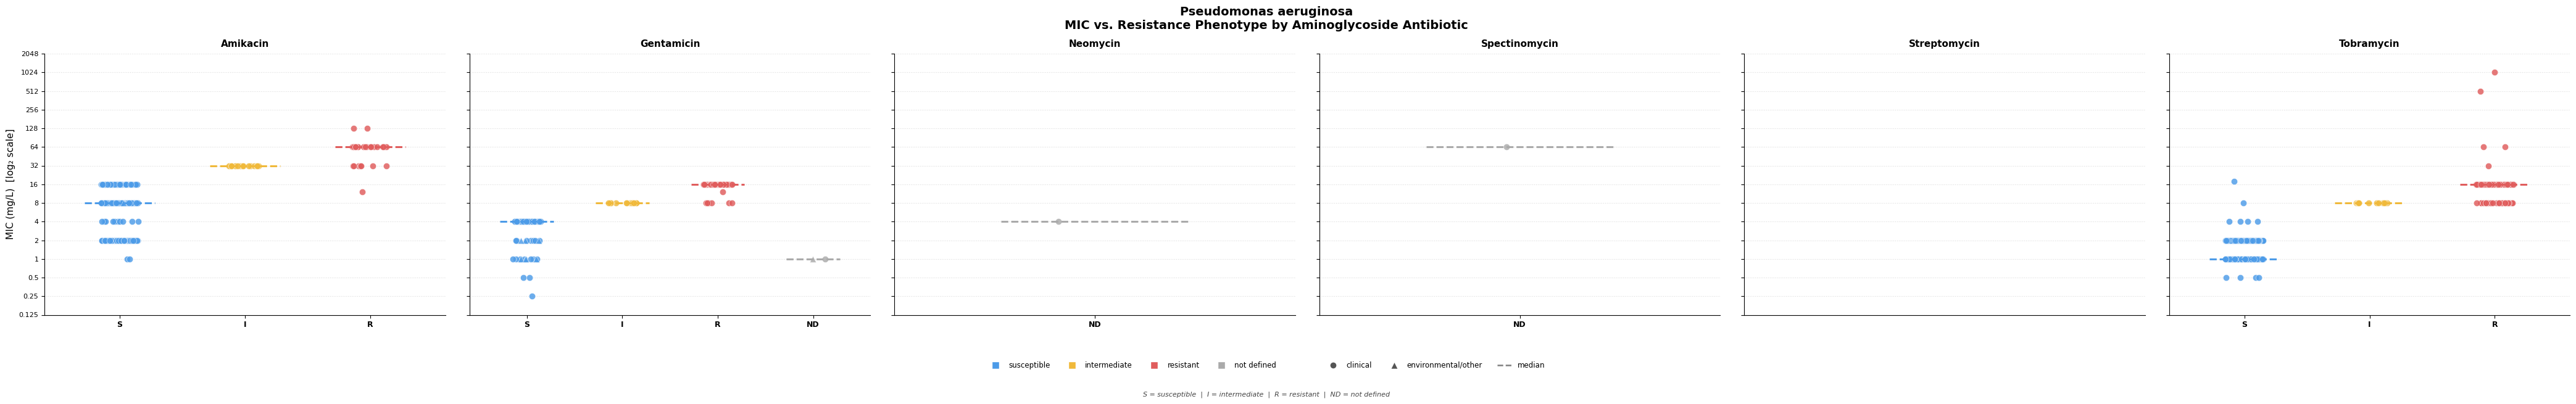

In [12]:
# ── 6b. Strip plot ────────────────────────────────────────────────────────────

def plot_mic_strip(
    plot_data: pd.DataFrame,
    species_name: str = "",
    ab_class: str = "",
    jitter: float = 0.15,
    rng_seed: int = 42,
) -> plt.Figure:
    """
    Jittered strip plot of MIC vs resistance phenotype per antibiotic,
    with isolation type encoded via marker shape and median lines.
    """
    RNG = np.random.default_rng(rng_seed)

    antibiotics      = sorted(plot_data["Antibiotic"].unique())
    present_phenotypes = [p for p in PHENO_ORDER
                          if p in plot_data["Resistance phenotype"].unique()]

    fig, axes = plt.subplots(
        1, len(antibiotics),
        figsize=(max(5, 2.2 * len(present_phenotypes)) * len(antibiotics), 5.5),
        sharey=True,
        gridspec_kw={"wspace": 0.06},
    )
    if len(antibiotics) == 1:
        axes = [axes]

    for ax, abx in zip(axes, antibiotics):
        sub = plot_data[
            (plot_data["Antibiotic"] == abx) & plot_data["MIC (mg/L)"].notna()
        ].copy()

        abx_phenotypes = [p for p in present_phenotypes
                          if p in sub["Resistance phenotype"].values]
        x_map = {p: i for i, p in enumerate(abx_phenotypes)}

        for phenotype in abx_phenotypes:
            ph_sub  = sub[sub["Resistance phenotype"] == phenotype]
            color   = PHENOTYPE_COLORS[phenotype]
            x_pos   = x_map[phenotype]

            for iso_type, marker in ISOLATION_MARKERS.items():
                iso_sub = ph_sub[ph_sub["Isolation type"] == iso_type]
                if iso_sub.empty:
                    continue
                mic_vals = iso_sub["MIC (mg/L)"].values
                x_jitter = x_pos + RNG.uniform(-jitter, jitter, len(mic_vals))
                ax.scatter(
                    x_jitter, np.log2(mic_vals),
                    color=color, marker=marker, s=55, alpha=0.82,
                    edgecolors="white", linewidths=0.4, zorder=3,
                )

            med = np.log2(ph_sub["MIC (mg/L)"].median())
            ax.hlines(med, x_pos - 0.28, x_pos + 0.28,
                      colors=color, linewidths=2.2, linestyles="--", zorder=4)

        ax.set_xticks(range(len(abx_phenotypes)))
        ax.set_xticklabels(
            [SHORT_LABELS[p] for p in abx_phenotypes],
            fontsize=9, fontweight="bold",
        )
        ax.set_xlim(-0.6, len(abx_phenotypes) - 0.4)
        ax.set_title(abx.capitalize(), fontsize=11, fontweight="bold", pad=8)
        ax.grid(axis="y", linestyle=":", alpha=0.45)
        ax.spines[["top", "right"]].set_visible(False)

    # Shared y-axis
    all_mic  = plot_data["MIC (mg/L)"].dropna()
    log2_min = int(np.floor(np.log2(all_mic.min()))) - 1
    log2_max = int(np.ceil(np.log2(all_mic.max()))) + 1
    log2_ticks = list(range(log2_min, log2_max + 1))
    axes[0].set_yticks(log2_ticks)
    axes[0].set_yticklabels([f"{2**int(t):.4g}" for t in log2_ticks], fontsize=8)
    axes[0].set_ylabel("MIC (mg/L)  [log₂ scale]", fontsize=11)

    # Legend
    handles = [
        plt.Line2D([0], [0], marker="s", color="w",
                   markerfacecolor=PHENOTYPE_COLORS[p], markersize=9, label=p)
        for p in present_phenotypes
    ]
    handles.append(plt.Line2D([], [], linestyle="none"))  # spacer
    for iso_type, marker in ISOLATION_MARKERS.items():
        handles.append(plt.Line2D(
            [0], [0], marker=marker, color="w",
            markerfacecolor="#555555", markersize=8, label=iso_type,
        ))
    handles.append(plt.Line2D(
        [0], [0], color="grey", linestyle="--", linewidth=1.8, label="median",
    ))
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.07))

    key_text = "  |  ".join(f"{SHORT_LABELS[p]} = {p}" for p in present_phenotypes)
    fig.text(0.5, -0.13, key_text, ha="center", fontsize=8,
             color="#444444", style="italic")

    fig.suptitle(
        f"{species_name}\nMIC vs. Resistance Phenotype by {ab_class} Antibiotic",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_mic_strip(plot_data, species_name=species_name, ab_class=ab_class)
fig.savefig(_save("mic_strip_plot"), dpi=250, bbox_inches="tight")
plt.show()

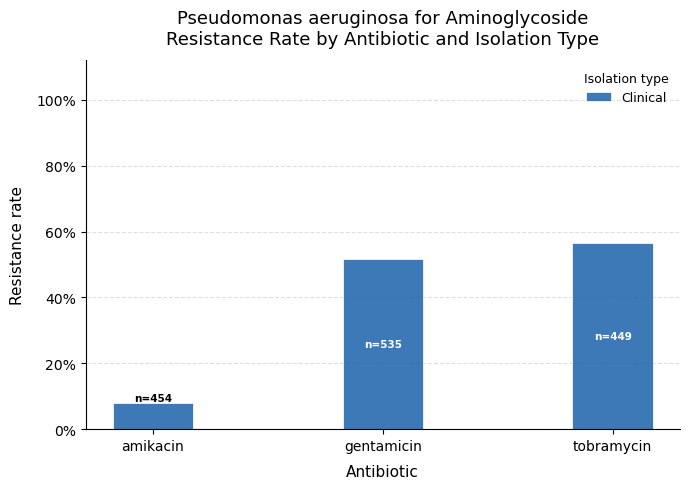

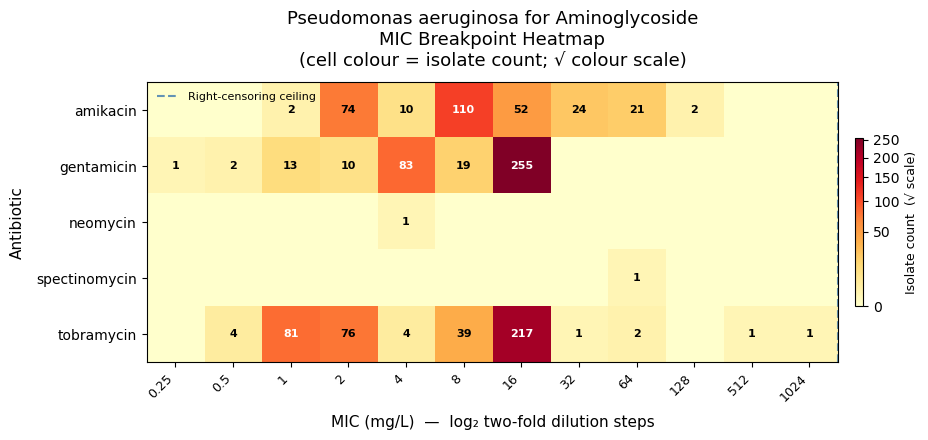

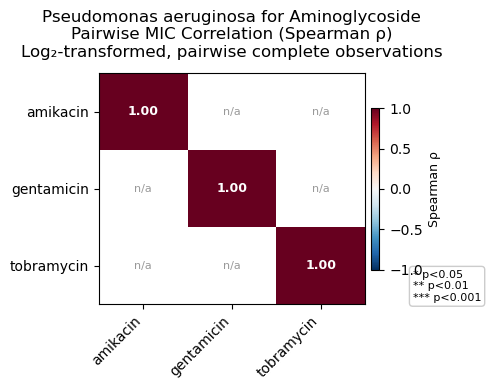

In [13]:
# ── 6c–6e. Resistance rate, breakpoint heatmap, pairwise correlation ─────────
# All three delegate to amr_plot_helpers — title_prefix carries species/class.

title = f"{species_name} for {ab_class}"

fig = plot_resistance_rate(
    plot_data,
    title_prefix=title,
    save_path=_save("resistance_rate_by_isolation_type"),
)
plt.show()

fig = plot_mic_breakpoint_heatmap(
    plot_data,
    title_prefix=title,
    save_path=_save("mic_breakpoint_heatmap"),
)
plt.show()

fig = plot_mic_pairwise_correlation(
    plot_data,
    title_prefix=title,
    save_path=_save("mic_pairwise_correlation"),
)
plt.show()

## SECTION 7 — Antibiotic merge-decision diagnostics


Class 'Aminoglycoside': 6 antibiotics, 15 pairwise comparisons.


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : amikacin
  Antibiotic B : gentamicin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  amikacin            : n=454
  gentamicin          : n=535

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  amikacin            : 8.4%  resistant  (n=430)
  gentamicin          : 53.5%  resistant  (n=516)
  Absolute difference  : 45.1%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
───────────────────────────────────────────────

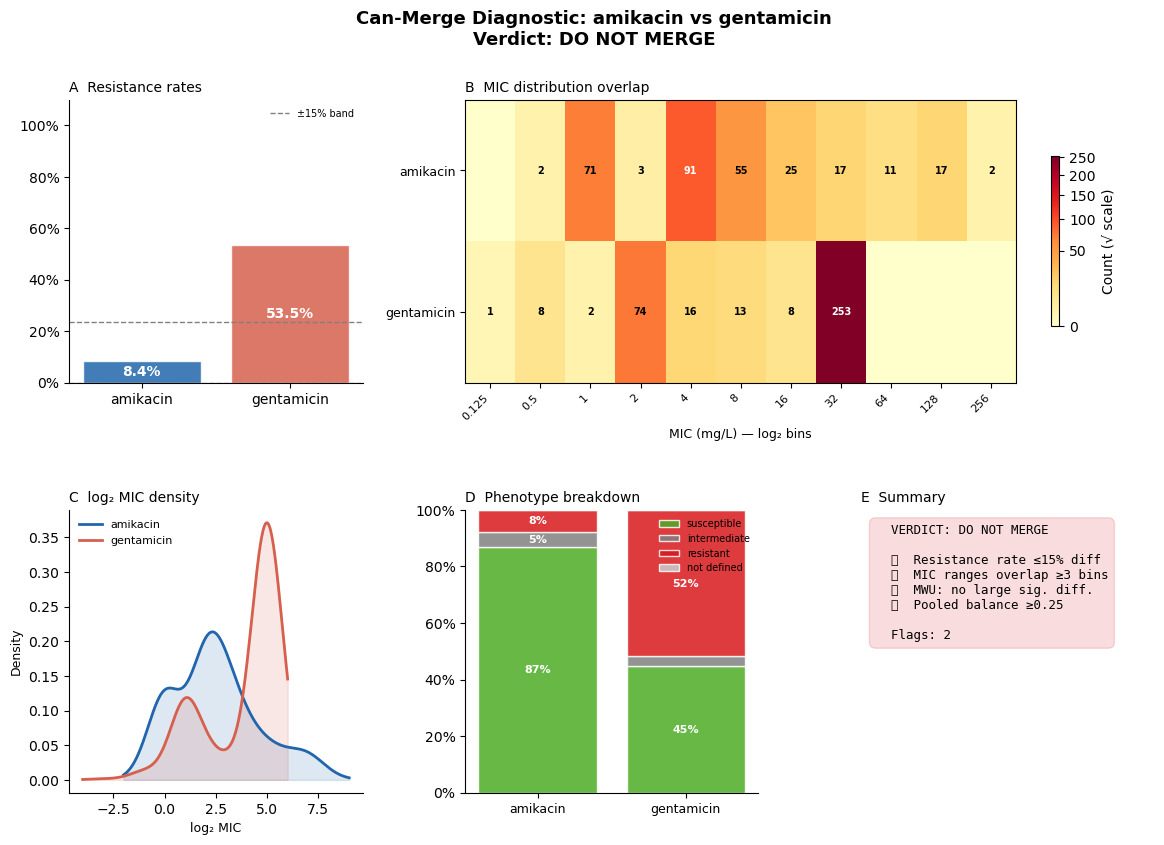


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : amikacin
  Antibiotic B : neomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  amikacin            : n=454
  neomycin            : n=1

  ⚠ Insufficient samples — amikacin n=454, neomycin n=1 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  amikacin            : 8.4%  resistant  (n=430)
  neomycin            : nan%  resistant  (n=0)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
───────────────────────────────────────────────────────

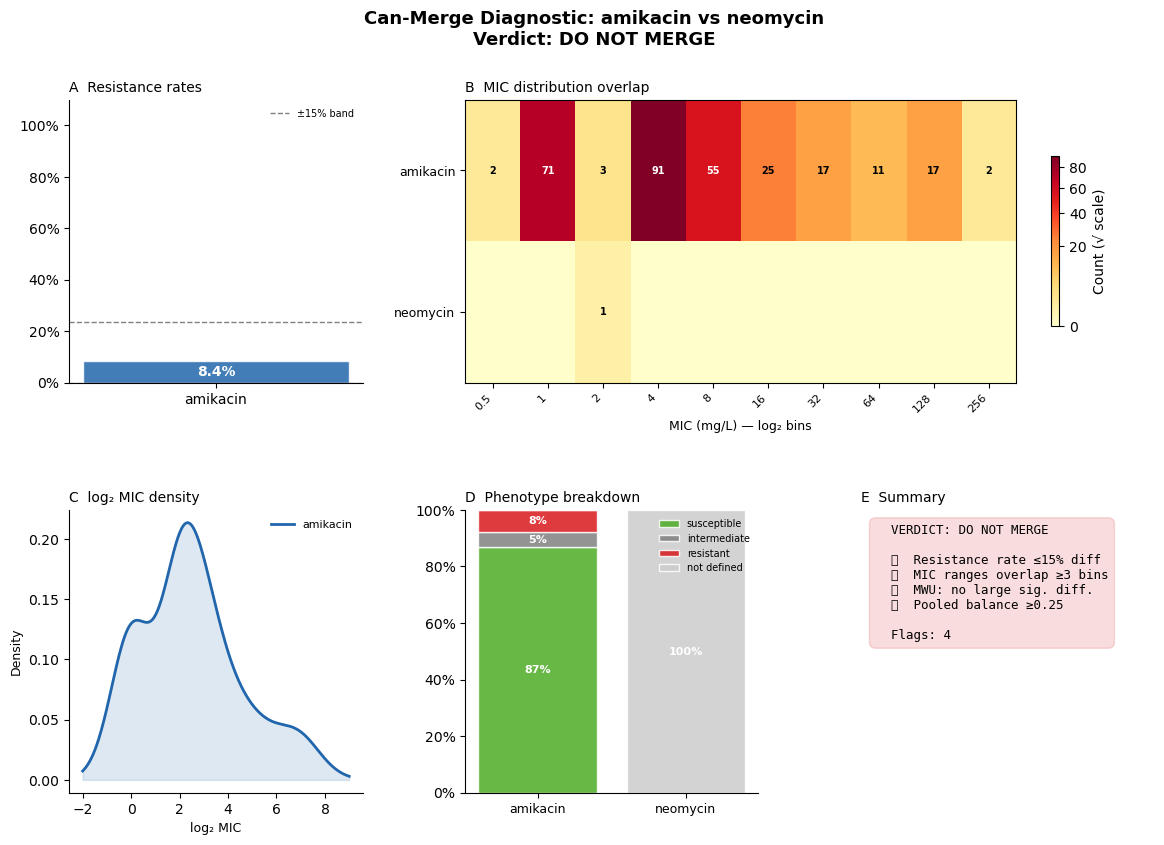


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : amikacin
  Antibiotic B : spectinomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  amikacin            : n=454
  spectinomycin       : n=1

  ⚠ Insufficient samples — amikacin n=454, spectinomycin n=1 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  amikacin            : 8.4%  resistant  (n=430)
  spectinomycin       : nan%  resistant  (n=0)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
─────────────────────────────────────────────

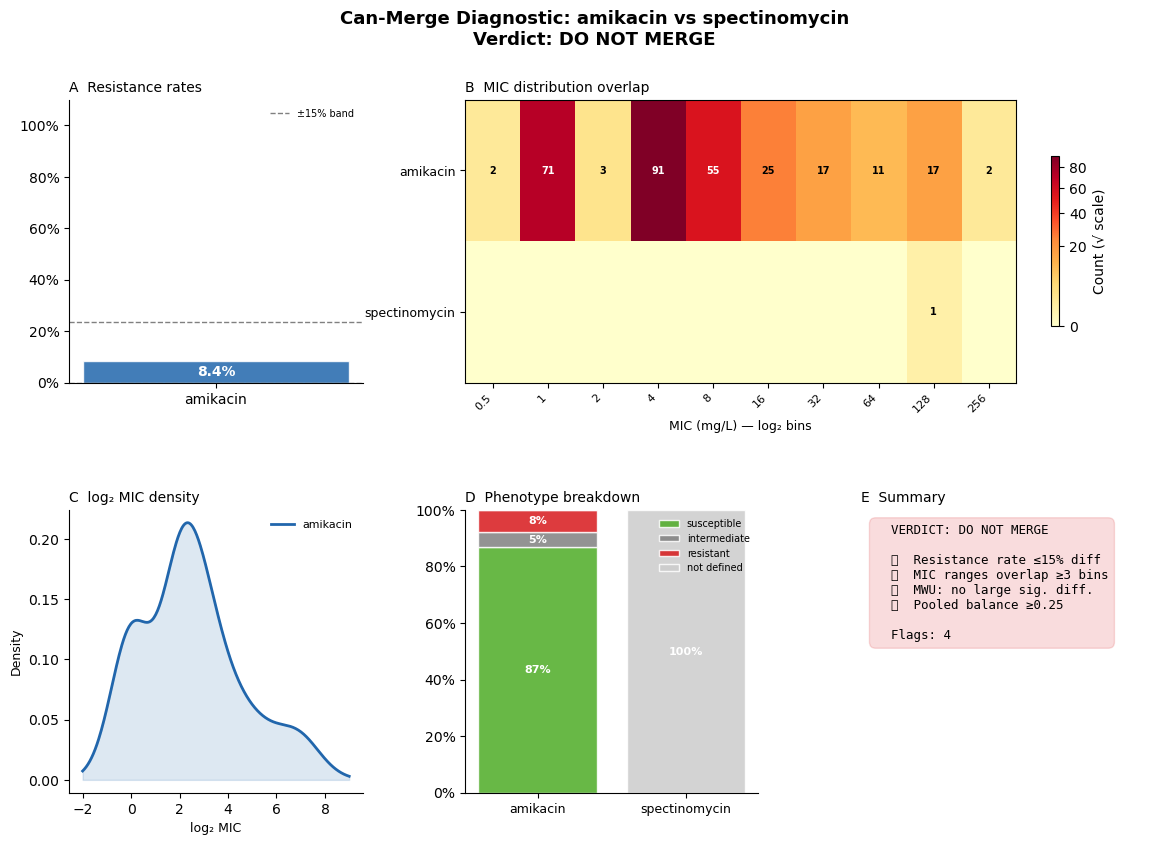


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : amikacin
  Antibiotic B : streptomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  amikacin            : n=454
  streptomycin        : n=3

  ⚠ Insufficient samples — amikacin n=454, streptomycin n=3 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  amikacin            : 8.4%  resistant  (n=430)
  streptomycin        : 66.7%  resistant  (n=3)
  Absolute difference  : 58.3%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
─────────────────────────────────────────────

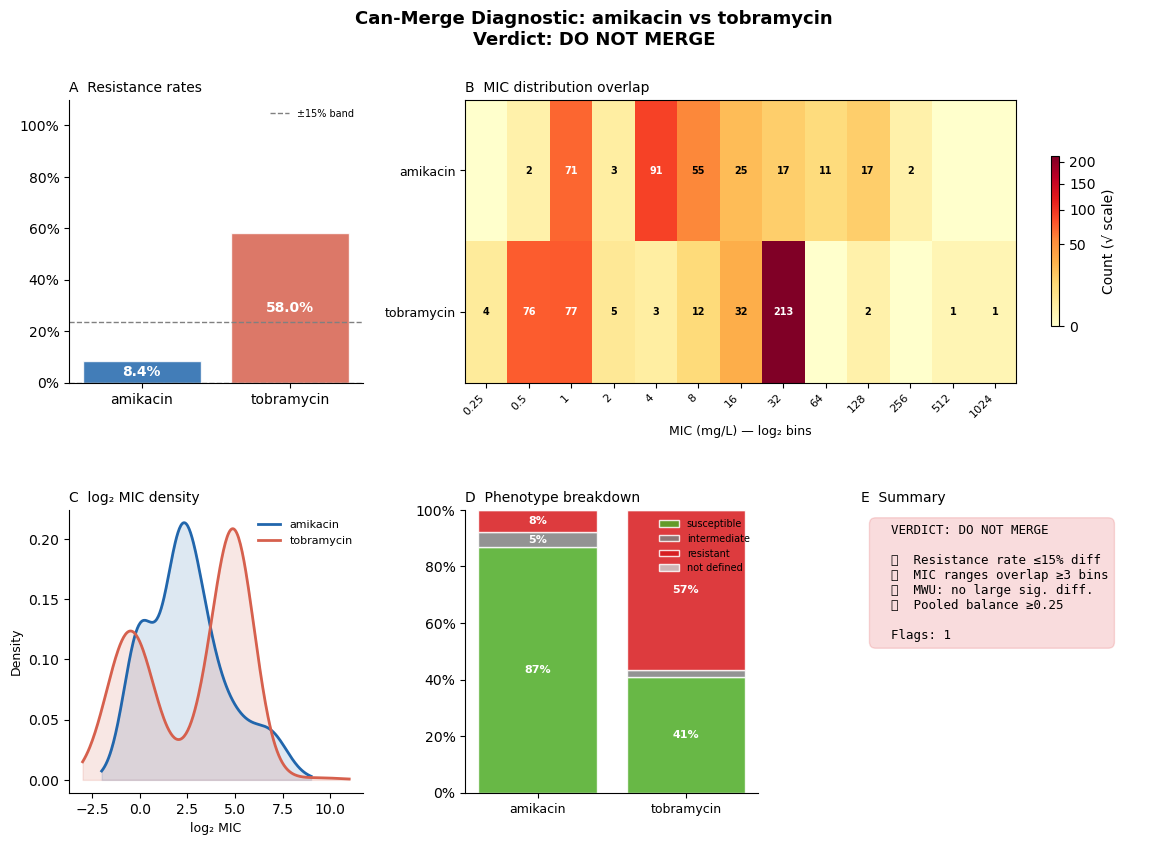


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : gentamicin
  Antibiotic B : neomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  gentamicin          : n=535
  neomycin            : n=1

  ⚠ Insufficient samples — gentamicin n=535, neomycin n=1 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  gentamicin          : 53.5%  resistant  (n=516)
  neomycin            : nan%  resistant  (n=0)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
──────────────────────────────────────────────────

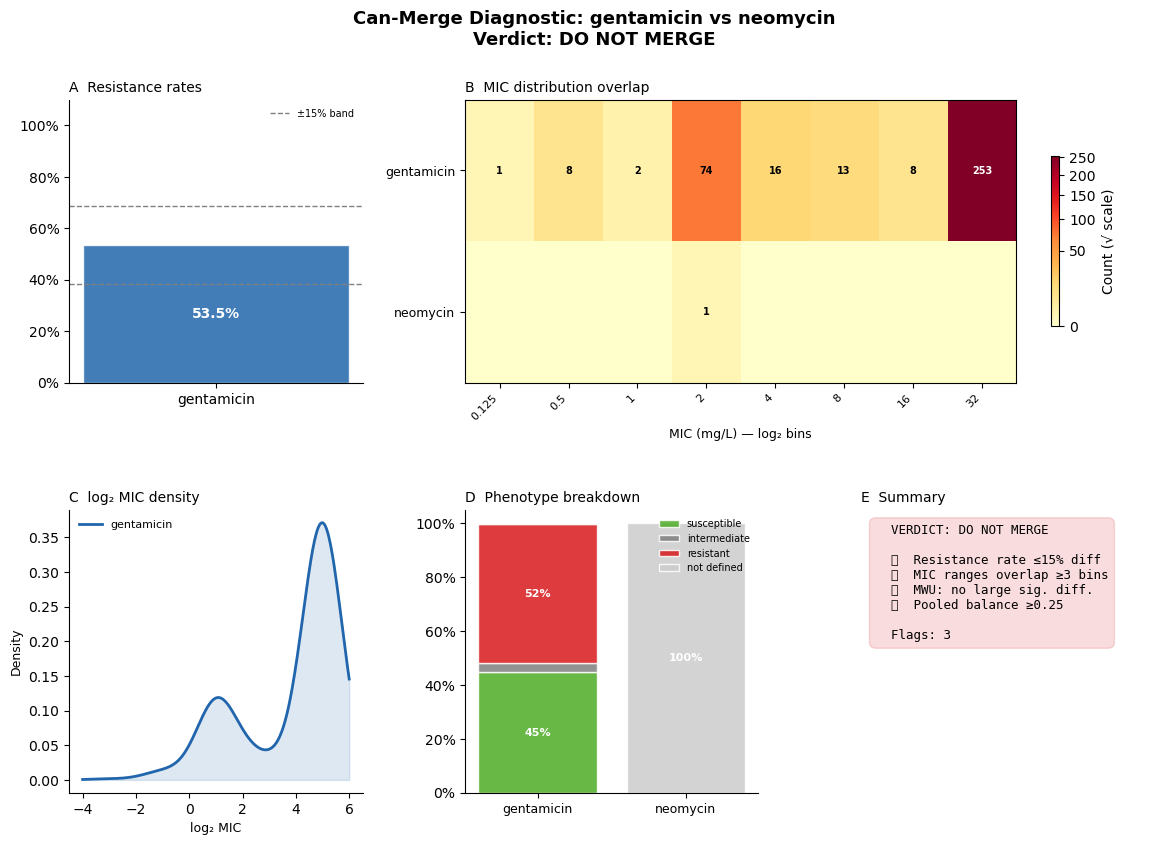


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : gentamicin
  Antibiotic B : spectinomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  gentamicin          : n=535
  spectinomycin       : n=1

  ⚠ Insufficient samples — gentamicin n=535, spectinomycin n=1 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  gentamicin          : 53.5%  resistant  (n=516)
  spectinomycin       : nan%  resistant  (n=0)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
────────────────────────────────────────

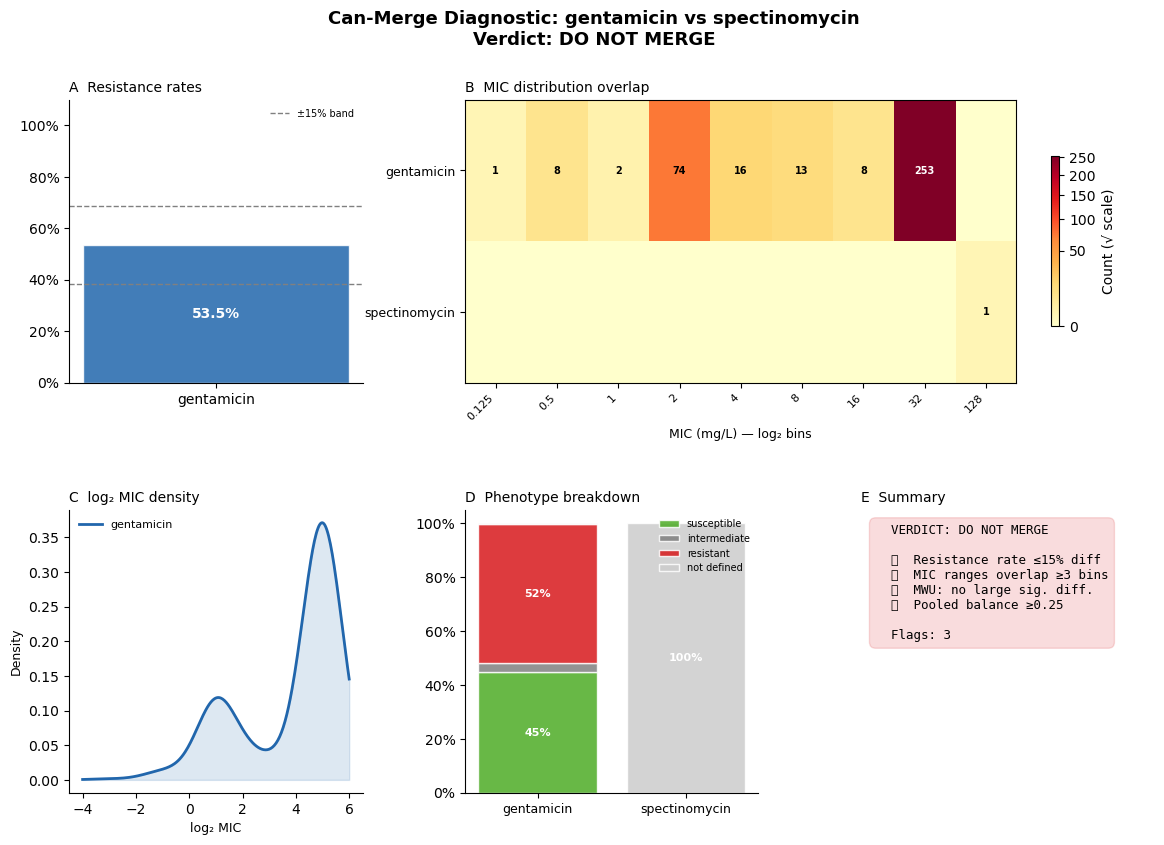


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : gentamicin
  Antibiotic B : streptomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  gentamicin          : n=535
  streptomycin        : n=3

  ⚠ Insufficient samples — gentamicin n=535, streptomycin n=3 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  gentamicin          : 53.5%  resistant  (n=516)
  streptomycin        : 66.7%  resistant  (n=3)
  Absolute difference  : 13.2%  (threshold=15%)
  Result               : ✅ Within threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
─────────────────────────────────────────

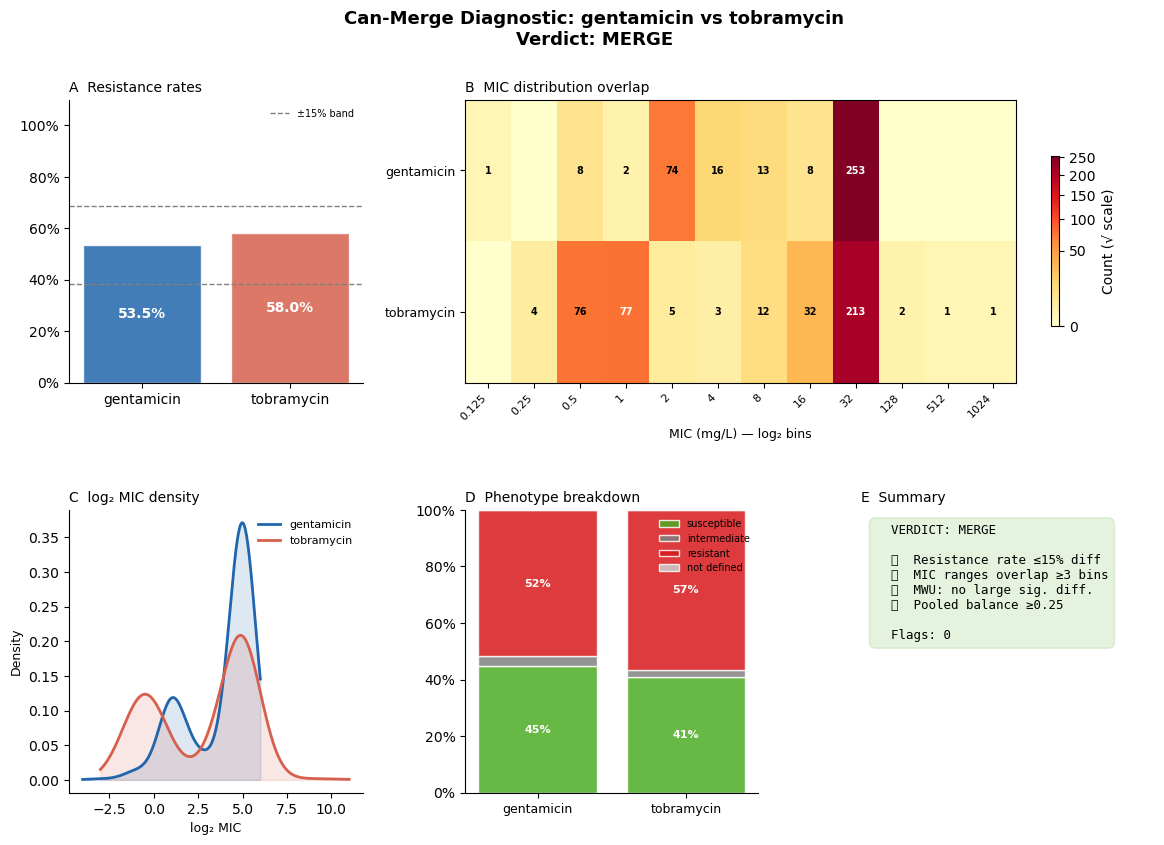


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : neomycin
  Antibiotic B : spectinomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  neomycin            : n=1
  spectinomycin       : n=1

  ⚠ Insufficient samples — neomycin n=1, spectinomycin n=1 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  neomycin            : nan%  resistant  (n=0)
  spectinomycin       : nan%  resistant  (n=0)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
───────────────────────────────────────────────────

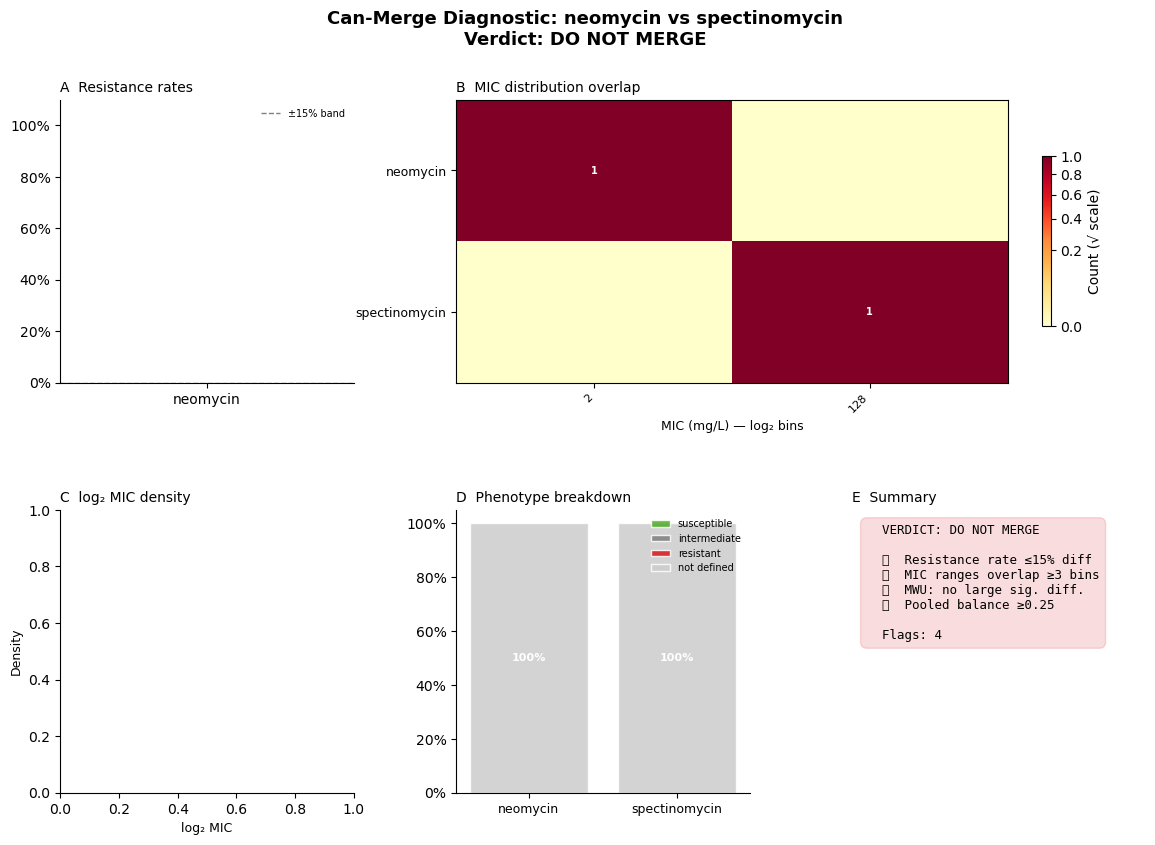


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : neomycin
  Antibiotic B : streptomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  neomycin            : n=1
  streptomycin        : n=3

  ⚠ Insufficient samples — neomycin n=1, streptomycin n=3 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  neomycin            : nan%  resistant  (n=0)
  streptomycin        : 66.7%  resistant  (n=3)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
────────────────────────────────────────────────────

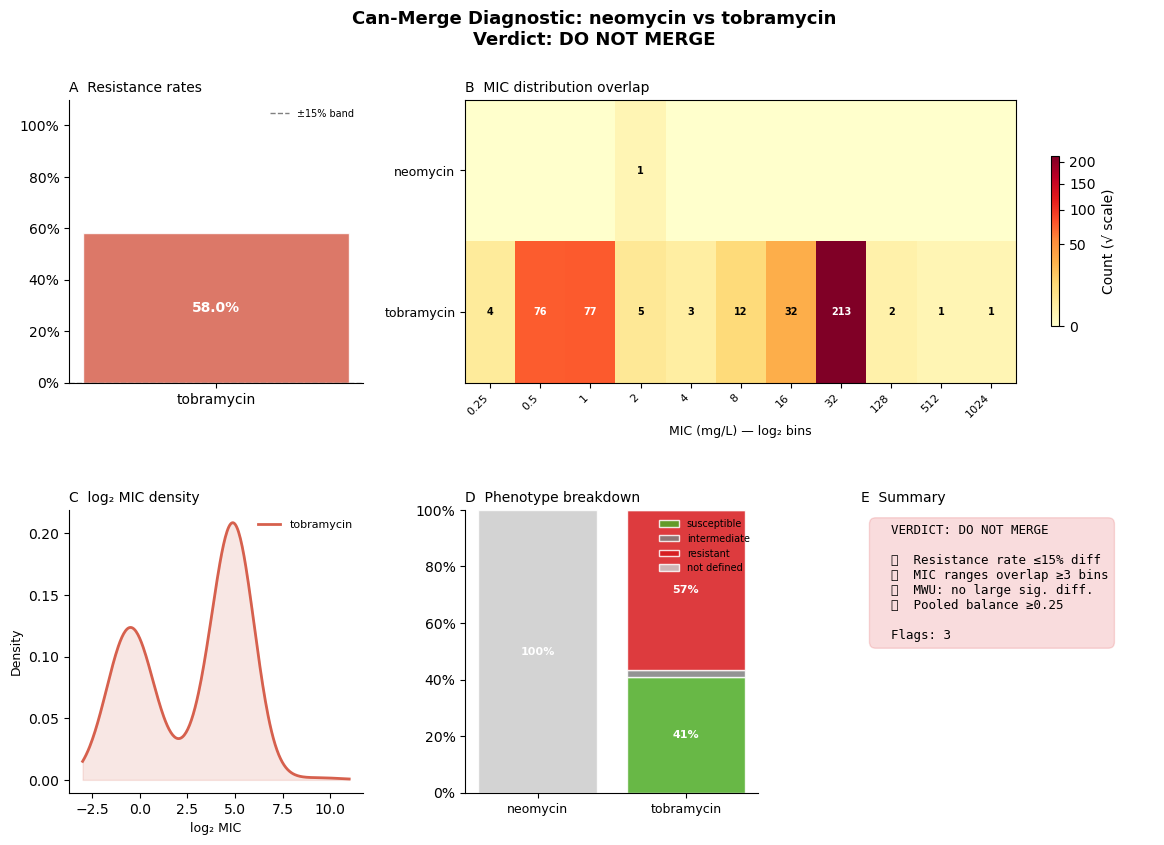


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : spectinomycin
  Antibiotic B : streptomycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  spectinomycin       : n=1
  streptomycin        : n=3

  ⚠ Insufficient samples — spectinomycin n=1, streptomycin n=3 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  spectinomycin       : nan%  resistant  (n=0)
  streptomycin        : 66.7%  resistant  (n=3)
  Absolute difference  : nan%  (threshold=15%)
  Result               : ❌ Exceeds threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
──────────────────────────────────────────

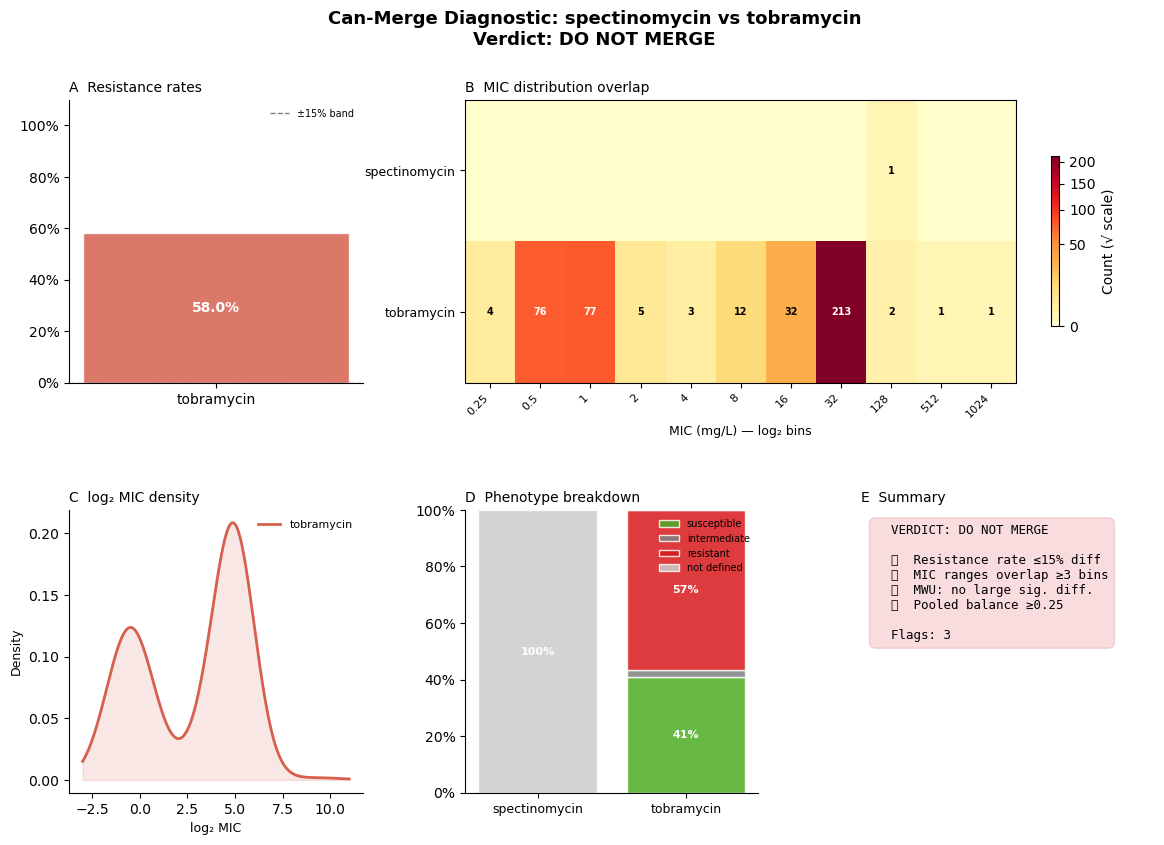


────────────────────────────────────────────────────────────
  CAN-MERGE DIAGNOSTIC
────────────────────────────────────────────────────────────
  Antibiotic A : streptomycin
  Antibiotic B : tobramycin
  Isolation    : clinical

────────────────────────────────────────────────────────────
  BLOCK 1 — Sample sizes
────────────────────────────────────────────────────────────
  streptomycin        : n=3
  tobramycin          : n=449

  ⚠ Insufficient samples — streptomycin n=3, tobramycin n=449 (min=30)

────────────────────────────────────────────────────────────
  BLOCK 2 — Resistance rate comparison
────────────────────────────────────────────────────────────
  streptomycin        : 66.7%  resistant  (n=3)
  tobramycin          : 58.0%  resistant  (n=438)
  Absolute difference  : 8.7%  (threshold=15%)
  Result               : ✅ Within threshold

────────────────────────────────────────────────────────────
  BLOCK 3 — MIC distribution overlap
──────────────────────────────────────────

In [14]:
summary = can_merge_class(
    df                   = selected_records,
    antibiotic_class     = ab_class,
    antibiotic_class_col = "Antibiotic_Class",
    isolation_filter     = "clinical",
    save_dir             = PLOTS_DIR,
)

print(summary)

In [15]:
model_data = selected_records[
    (selected_records['Antibiotic'].isin(['gentamicin', 'amikacin', 'tobramycin'])) & 
    (selected_records['Resistance phenotype'].isin(['susceptible', 'resistant', 'intermediate']))]

class_map = {
    "susceptible" : "susceptible",
    "resistant" : "non-susceptible",
    "intermediate" : "non-susceptible"
}

model_data['binary_class'] = model_data['Resistance phenotype'].map(class_map)

In [16]:
# Check distribution per antibiotic (not just combined)
model_data.groupby(['Antibiotic', 'binary_class']).size().unstack()

binary_class,non-susceptible,susceptible
Antibiotic,,
amikacin,60,395
gentamicin,294,247
tobramycin,265,184


In [17]:
model_data['binary_class'].value_counts()

binary_class
susceptible        826
non-susceptible    619
Name: count, dtype: int64

In [18]:
model_data['Assembly_Accession'].nunique()

625

In [19]:
# Create species-specific output directory
save_path = (
    f"/Users/akshayonly/Main/Projects/amr-geno2dock/fresh_approach/data/"
    f"{species_name.replace(' ', '_').lower()}"
)

os.makedirs(save_path, exist_ok=True)

# Save model dataset
model_csv_path = os.path.join(save_path, "model_data.csv")

model_data.reset_index(drop=True).to_csv(
    model_csv_path,
    index=False
)

# Prepare accession filename
species_slug = species_name.replace(' ', '_').lower()
antibiotic_slug = ab_class.replace(' ', '_').lower()

output_filename = (
    f"{species_slug}_{antibiotic_slug}_accessions.txt"
)

accession_path = os.path.join(save_path, output_filename)

# Export accession list
model_data["Assembly_Accession"].drop_duplicates().to_csv(
    accession_path,
    index=False,
    header=False
)

print(
    f"Exported "
    f"{model_data['Assembly_Accession'].nunique()} accessions "
    f"to '{accession_path}'"
)

print("Ready for downloading genome assemblies.")

Exported 625 accessions to '/Users/akshayonly/Main/Projects/amr-geno2dock/fresh_approach/data/pseudomonas_aeruginosa/pseudomonas_aeruginosa_aminoglycoside_accessions.txt'
Ready for downloading genome assemblies.
